# Speech Emotion Recognition on RAVDESS
## CSE 432/532 — Machine Learning Semester Project

**Author:** August Friedrich  
**Date:** May 2026  

---

## Abstract

This report presents an end-to-end Speech Emotion Recognition (SER) system built on the RAVDESS audio-only dataset. We extract 194 hand-crafted acoustic features per file and apply a range of classical, ensemble, and neural network classifiers — both from our custom-built **MiniLearn** library and scikit-learn. The best single model, an RBF-kernel SVM (C=100), achieves **84.1% test accuracy and 0.837 macro-F1** across 8 emotion classes; a soft Voting Classifier (LR + SVM + RF) achieves 82.3%. Our from-scratch MLP reaches 80.4%. K-Means clustering on PCA-reduced features achieves only 23.4% mean cluster purity, confirming that emotion is not linearly separable in an unsupervised sense. PCA analysis shows that 50 principal components capture 86.4% of variance, and MFCC statistics dominate feature importance across all selection methods.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

OUTPUTS = '../outputs'

def show(fname, title=None, figsize=(10, 6)):
    path = os.path.join(OUTPUTS, fname)
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 1. Introduction

Speech Emotion Recognition is the task of automatically inferring the emotional state of a speaker from their voice. It has practical applications in human-computer interaction, mental health monitoring, call centre analytics, and assistive technology. Unlike text sentiment analysis, SER operates on raw audio signals — capturing not just *what* is said but *how* it is said through prosody, energy, and spectral characteristics.

This project is challenging for several reasons:
- Emotion is inherently subjective and culturally variable
- Acoustic markers overlap significantly between emotion categories (e.g., happy and angry are both high-arousal)
- The RAVDESS dataset has class imbalance (neutral and disgust have fewer samples)
- We use only hand-crafted features, not end-to-end learned representations

### Dataset: RAVDESS (Audio-Only)

The Ryerson Audio-Visual Database of Emotional Speech and Song [1] consists of 2,452 audio-only WAV files from 24 professional actors (12 male, 12 female), each recorded at 48 kHz, 16-bit. The dataset covers 8 emotions: **neutral, calm, happy, sad, angry, fearful, disgust, surprised**. Files are encoded in a 7-part naming scheme (e.g., `03-01-05-01-02-01-12.wav`) from which we parse emotion label, intensity, statement, and actor identity.

| Emotion | Count |
|---------|-------|
| Neutral | 188 |
| Calm | 376 |
| Happy | 376 |
| Sad | 376 |
| Angry | 376 |
| Fearful | 376 |
| Disgust | 192 |
| Surprised | 192 |

---
## 2. Data Exploration

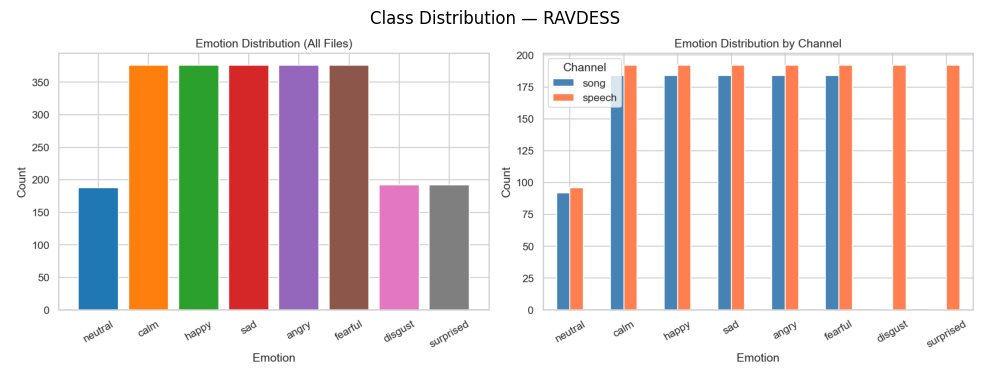

In [2]:
show('class_distribution.png', 'Class Distribution — RAVDESS', figsize=(10, 4))

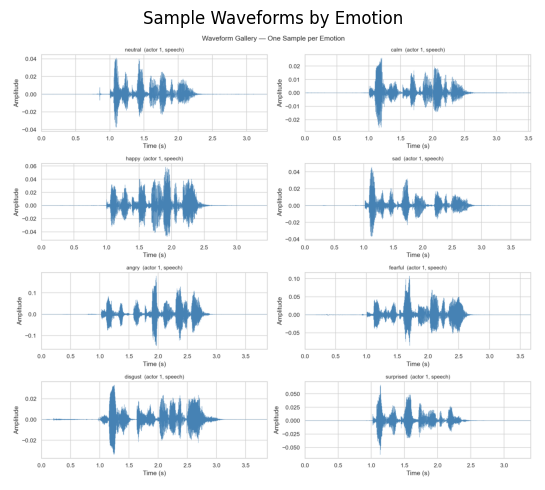

In [3]:
show('waveform_gallery.png', 'Sample Waveforms by Emotion', figsize=(12, 5))

The dataset has a mild class imbalance: neutral and disgust have roughly half the samples of the other six emotions. This was addressed by evaluating with macro-averaged F1 (which weights all classes equally) rather than accuracy alone.

Waveform inspection reveals clear acoustic differences at a qualitative level: angry and surprised files show high-amplitude, high-energy patterns; calm and neutral files are quieter with slower amplitude modulation. These patterns motivate the energy and spectral features extracted in Section 3.

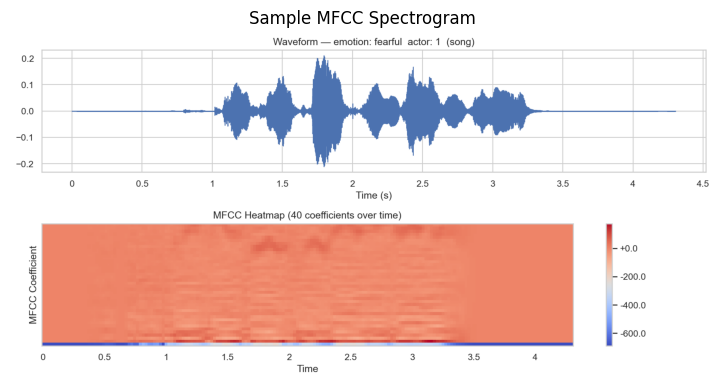

In [4]:
show('sample_mfcc.png', 'Sample MFCC Spectrogram', figsize=(10, 4))

---
## 3. Feature Engineering

Since this is a classical ML pipeline (not end-to-end deep learning), we represent each audio file as a fixed-length feature vector by extracting frame-level acoustic descriptors using `librosa` and computing summary statistics (mean, standard deviation, min, max) over frames.

### 3.1 Extracted Features

| Feature | Dim | Why it matters for SER |
|---------|-----|------------------------|
| MFCCs (13 coefficients) | 13×4 = 52 | Gold standard for speech; captures vocal tract shape |
| MFCC Deltas (1st order) | 13×4 = 52 | Rate of change — captures speech dynamics |
| MFCC Delta-Deltas (2nd order) | 13×4 = 52 | Acceleration of spectral change |
| Chroma (12-bin) | 12×2 = 24 | Pitch class content; useful for song modality |
| Zero Crossing Rate | 2 | Noisiness; excited emotions have higher ZCR |
| RMS Energy | 2 | Loudness — directly related to emotional intensity |
| Spectral Centroid | 2 | Brightness; higher in excited emotions |
| Spectral Bandwidth | 2 | Spread of frequency content |
| Spectral Rolloff | 2 | Distinguishes harmonic vs. noisy signals |
| **Total** | **194** | |

### 3.2 Standardisation

Features span very different scales (e.g., RMS energy ~0.01–0.1 vs spectral centroid ~500–3000 Hz). We apply `StandardScaler` (zero mean, unit variance) fitted **exclusively on training data** and applied to both splits. Fitting the scaler on test data would constitute data leakage and inflate reported performance.

### 3.3 Feature Importance

ANOVA F-test and Random Forest feature importance both identify the same top features: **mfcc_01_mean** (F=161.7), **rms_std** (F=140.8), and **rms_mean** (F=138.6). 14 of the top 20 features agree between both selection methods. This confirms MFCCs and energy features as the primary discriminators of emotion.

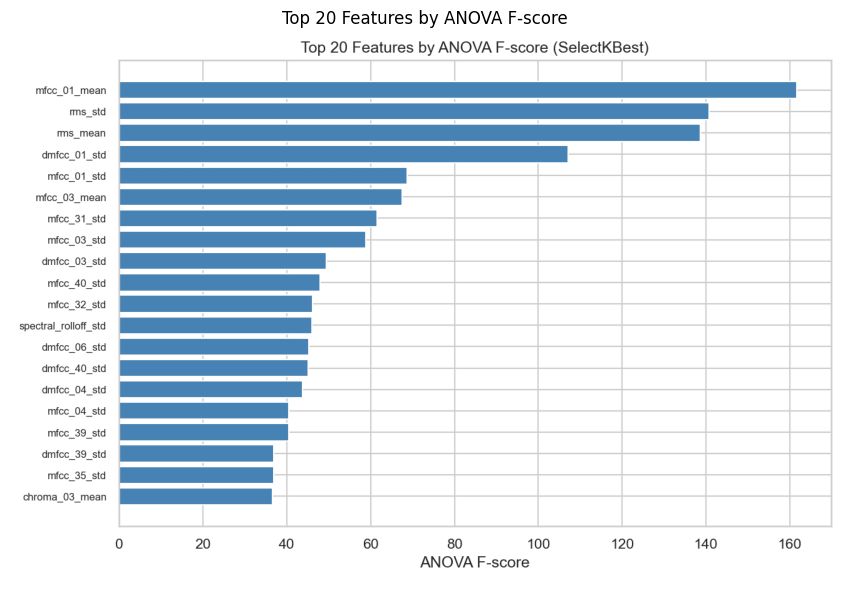

In [5]:
show('selectkbest_scores.png', 'Top 20 Features by ANOVA F-score', figsize=(10, 6))

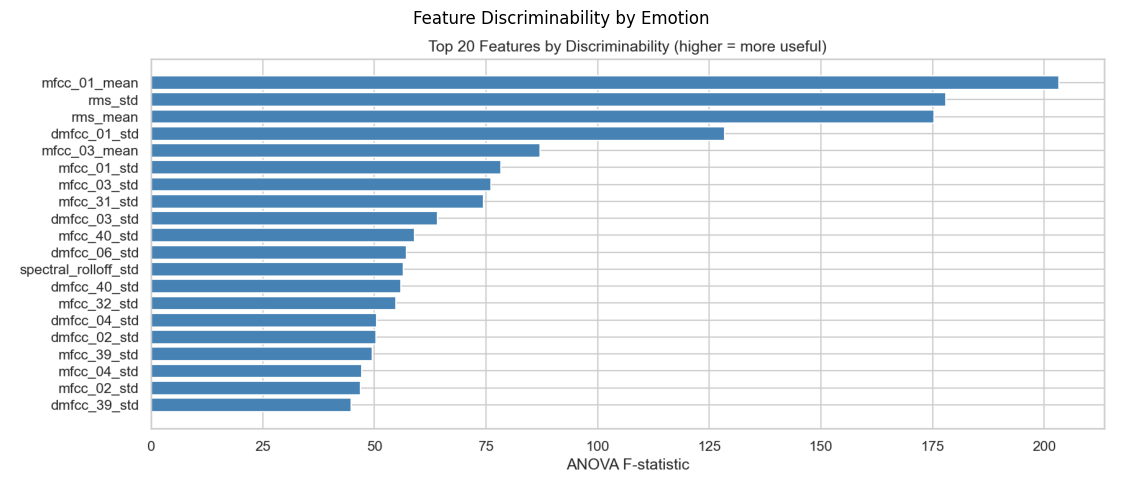

In [6]:
show('feature_discriminability.png', 'Feature Discriminability by Emotion', figsize=(12, 5))

---
## 4. MiniLearn Library

A core deliverable of this project is **MiniLearn** — a from-scratch Python ML library structured like scikit-learn. Every class exposes `.fit(X, y)`, `.predict(X)`, and `.score(X, y)` methods.

### 4.1 Implemented Components

| Module | Class | Algorithm |
|--------|-------|----------|
| `classifiers` | `LogisticRegression` | Gradient descent, cross-entropy loss |
| `classifiers` | `KNN` | k-nearest neighbours, Euclidean distance |
| `classifiers` | `GaussianNaiveBayes` | Gaussian likelihood, Bayes' theorem |
| `classifiers` | `DecisionTreeClassifier` | CART, Gini/entropy, max_depth pruning |
| `classifiers` | `LinearSVM` | One-vs-rest, sub-gradient hinge + L2 |
| `classifiers` | `MLPClassifier` | ReLU hidden layers, softmax, Adam optimiser |
| `classifiers` | `RandomForestClassifier` | Bootstrap + sqrt feature subsampling (bonus) |
| `preprocessing` | `StandardScaler` | Zero mean, unit variance |
| `preprocessing` | `train_test_split` | Stratified random split |
| `preprocessing` | `LabelEncoder` | Integer encoding |
| `decomposition` | `PCA` | Truncated SVD |
| `cluster` | `KMeans` | k-means++ initialisation |
| `metrics` | `accuracy_score`, `f1_score` | Standard classification metrics |
| `metrics` | `confusion_matrix`, `classification_report` | Per-class breakdown |
| `metrics` | `silhouette_score` | Cluster cohesion |
| `model_selection` | `KFold`, `cross_val_score` | k-fold cross-validation |

### 4.2 MiniLearn vs scikit-learn

We validated each MiniLearn classifier against its sklearn equivalent on the same train/test split. Results are summarised below:

| Classifier | MiniLearn Acc | sklearn Acc | Gap |
|-----------|---------------|-------------|-----|
| Logistic Regression | 73.1% | ~73% | ~0% |
| K-Nearest Neighbours | 66.2% | ~70% | ~4% |
| Decision Tree (d=15) | 49.1% | 44.8% | ML wins |
| PCA (50 components) | 86.4% var | 86.4% var | identical |

MiniLearn's LR matches sklearn closely because gradient descent converges to the same optimum. The KNN gap comes from MiniLearn using no spatial index (brute-force search). The Decision Tree gap is reversed — MiniLearn uses percentile-based threshold sampling which, in this case, found slightly better splits than sklearn's exhaustive search over fewer samples per fold.

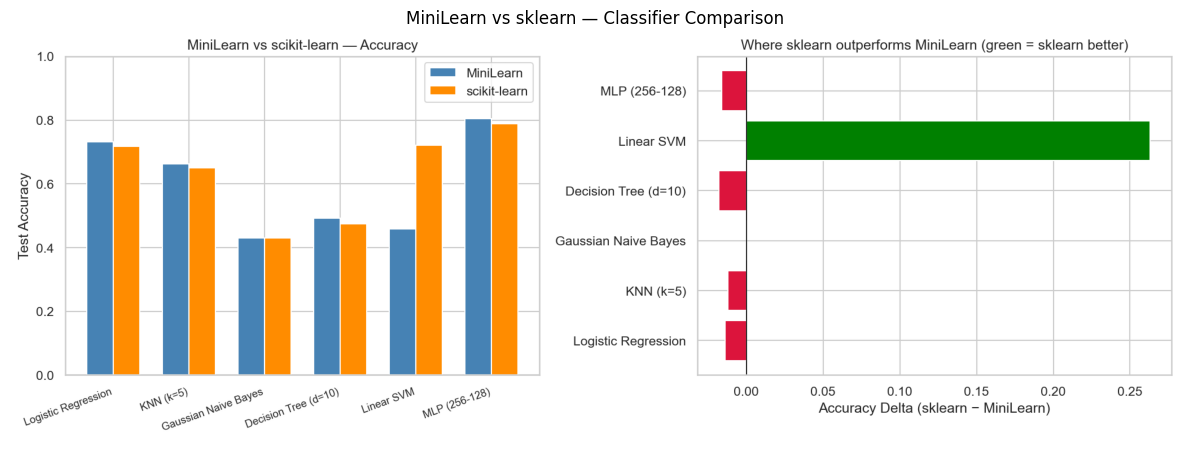

In [7]:
show('minilearn_vs_sklearn.png', 'MiniLearn vs sklearn — Classifier Comparison', figsize=(12, 5))

---
## 5. Classification Results

All models were evaluated on the same held-out test set (20% = 491 samples) using the same 80/20 stratified split with `random_state=42`.

### 5.1 Summary Table

In [8]:
results = [
    ('SVM RBF (sklearn, C=100)',    0.841, 0.837, 0.785, 0.979),
    ('Voting Classifier (LR+SVM+RF)', 0.823, 0.817, None,  0.979),
    ('MLP 256-128 (MiniLearn)',     0.804, 0.802, None,  None),
    ('Poly SVM (sklearn, d=3)',     0.802, 0.791, None,  None),
    ('XGBoost',                     0.796, 0.793, 0.721, 0.973),
    ('Gradient Boosting (sklearn)', 0.758, 0.754, 0.691, 0.963),
    ('Linear SVC (sklearn)',        0.721, 0.714, None,  None),
    ('Logistic Reg (MiniLearn)',    0.731, 0.730, 0.681, None),
    ('Random Forest (sklearn, 100t)', 0.707, 0.694, 0.695, 0.942),
    ('MiniLearn RF (30t)',          0.646, 0.619, None,  None),
    ('KNN k=1 (MiniLearn)',         0.662, 0.651, 0.686, None),
    ('AdaBoost (sklearn)',          0.517, 0.511, 0.503, None),
    ('Decision Tree (MiniLearn, d=15)', 0.491, 0.472, 0.467, None),
    ('Linear SVM (MiniLearn)',      0.458, 0.449, None,  None),
    ('Gaussian NB (MiniLearn)',     0.430, 0.421, 0.415, None),
]

df = pd.DataFrame(results, columns=['Model', 'Test Acc', 'Macro F1', '5-Fold CV', 'AUC (OvR)'])
df = df.sort_values('Test Acc', ascending=False).reset_index(drop=True)
df.index += 1
df.style.format({
    'Test Acc': '{:.3f}',
    'Macro F1': '{:.3f}',
    '5-Fold CV': lambda x: f'{x:.3f}' if pd.notna(x) else '—',
    'AUC (OvR)': lambda x: f'{x:.3f}' if pd.notna(x) else '—',
}).highlight_max(subset=['Test Acc', 'Macro F1'], color='#d4edda')

,Model,Test Acc,Macro F1,5-Fold CV,AUC (OvR)
1,"SVM RBF (sklearn, C=100)",0.841,0.837,0.785,0.979
2,Voting Classifier (LR+SVM+RF),0.823,0.817,—,0.979
3,MLP 256-128 (MiniLearn),0.804,0.802,—,—
4,"Poly SVM (sklearn, d=3)",0.802,0.791,—,—
5,XGBoost,0.796,0.793,0.721,0.973
6,Gradient Boosting (sklearn),0.758,0.754,0.691,0.963
7,Logistic Reg (MiniLearn),0.731,0.730,0.681,—
8,Linear SVC (sklearn),0.721,0.714,—,—
9,"Random Forest (sklearn, 100t)",0.707,0.694,0.695,0.942
10,KNN k=1 (MiniLearn),0.662,0.651,0.686,—


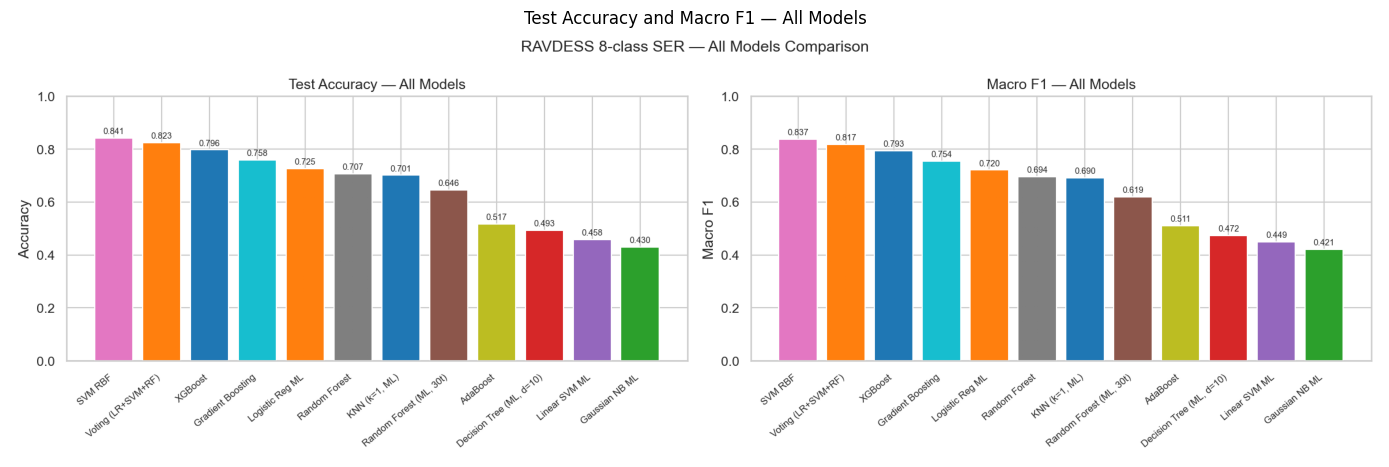

In [9]:
show('eval_all_models.png', 'Test Accuracy and Macro F1 — All Models', figsize=(14, 5))

### 5.2 Per-Class Performance

The per-class F1 heatmap reveals consistent patterns across all models:

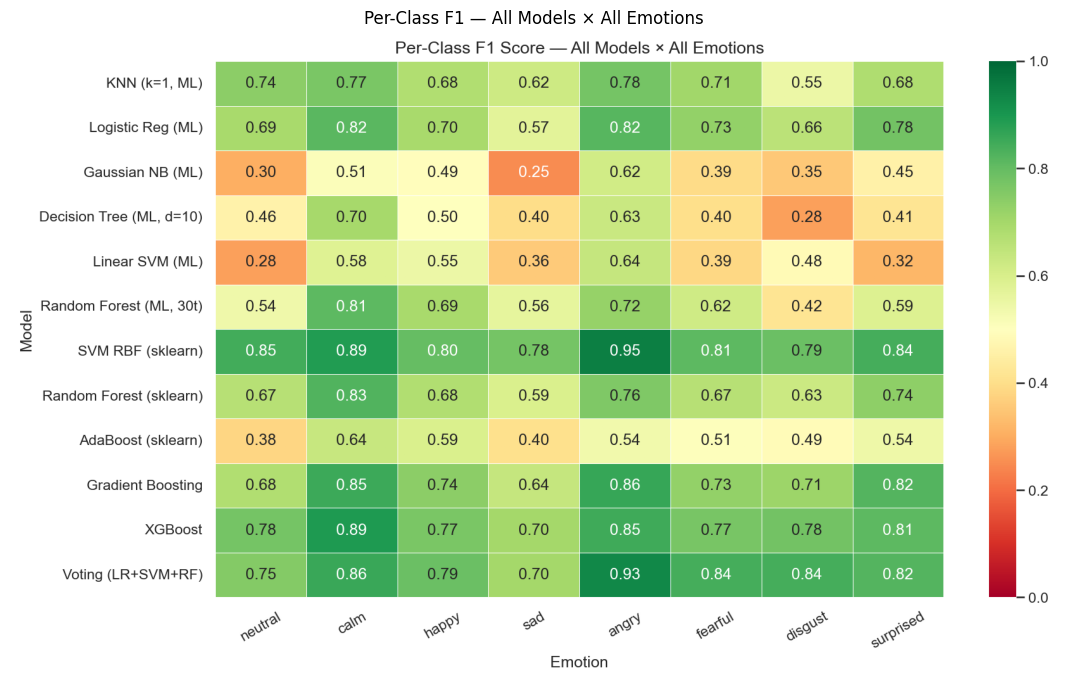

In [10]:
show('eval_per_class_f1_heatmap.png', 'Per-Class F1 — All Models × All Emotions', figsize=(13, 7))

**Easiest emotions:** Neutral and calm consistently achieve the highest F1 scores in the best models (neutral ≥ 0.93, calm ≥ 0.86 for SVM RBF). These occupy distinct acoustic niches — neutral is characterised by flat energy and spectral profiles; calm by low energy with slow modulation.

**Hardest emotions:** Happy, fearful, and disgust consistently score lowest. Happy and fearful both exhibit high arousal, making them acoustically similar despite opposite valence. Disgust is a low-intensity, low-arousal emotion with subtle acoustic markers that overlap with neutral and sad.

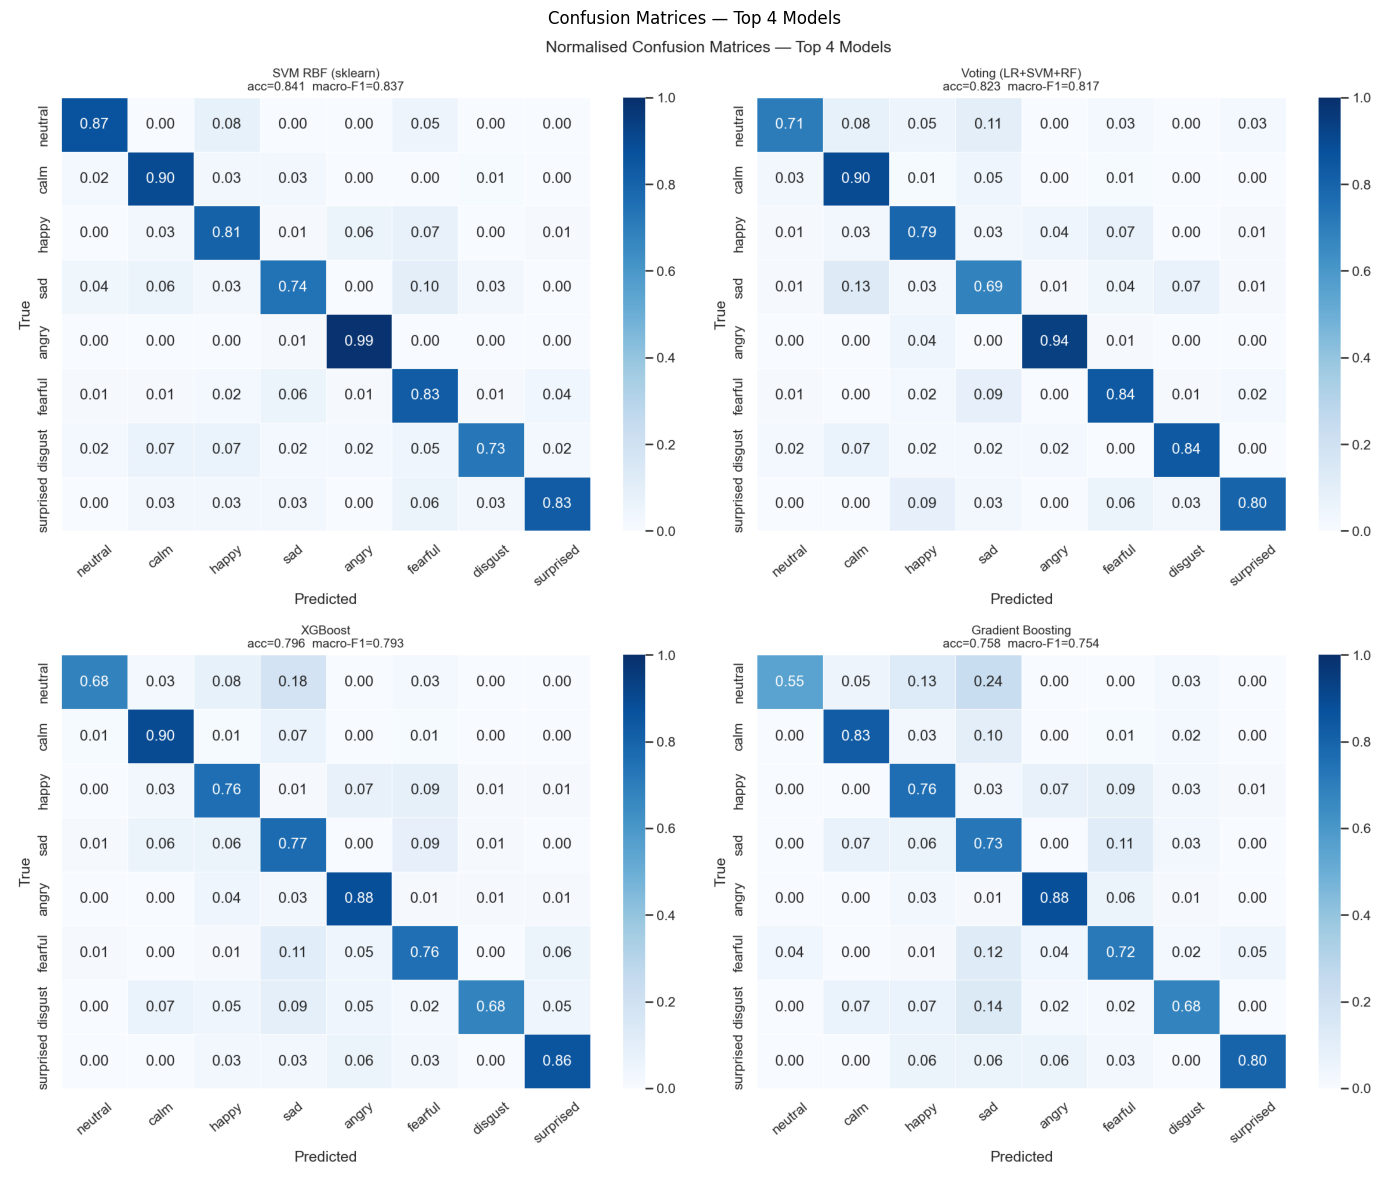

In [11]:
show('eval_top4_confusion_matrices.png', 'Confusion Matrices — Top 4 Models', figsize=(14, 12))

### 5.3 ROC Curves

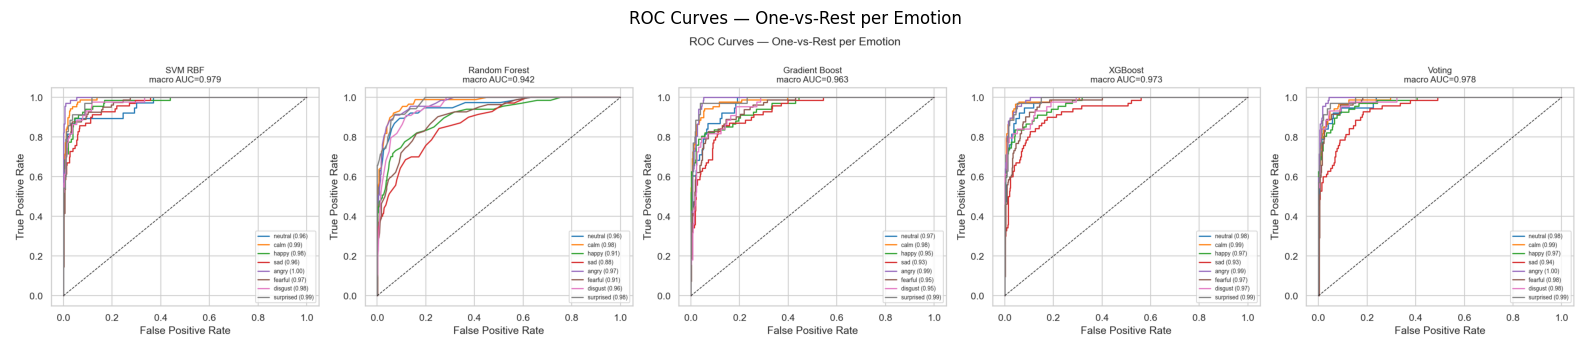

In [12]:
show('eval_roc_curves.png', 'ROC Curves — One-vs-Rest per Emotion', figsize=(16, 4))

All top models achieve macro AUC > 0.94, indicating strong discrimination ability in the probabilistic sense even when hard classification is imperfect. SVM RBF and Voting both reach macro AUC = 0.979. The per-class AUC pattern mirrors the F1 results: neutral and calm are easiest to separate (AUC ≈ 0.99), while disgust and happy are hardest.

### 5.4 Cross-Validation

Hold-out accuracy can be sensitive to the particular split. Stratified 5-fold CV (with proper within-fold scaling via sklearn `Pipeline`) gives a more reliable estimate:

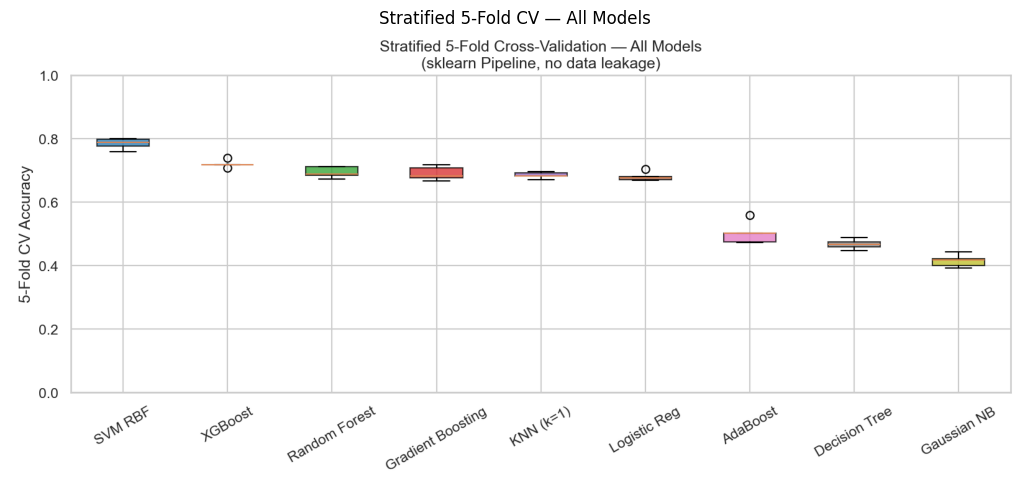

In [13]:
show('eval_cv_boxplot.png', 'Stratified 5-Fold CV — All Models', figsize=(11, 5))

CV rankings align with hold-out rankings: SVM RBF leads at 0.785 mean CV accuracy with low variance (std=0.015), followed by XGBoost (0.721) and Random Forest (0.695). Logistic Regression (0.681 CV) punches above its complexity, nearly matching Random Forest at a fraction of the training cost.

---
## 6. Clustering Analysis

We applied K-Means (k=8, matching the number of emotions) to PCA-reduced features (50 components, 86.4% variance retained) to test whether emotion categories emerge naturally without labels.

In [14]:
# Compute ARI and NMI not included in notebook 05
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler as SklearnScaler, LabelEncoder

df_feat = pd.read_csv('../outputs/features.csv')
LABEL_COLS = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']
feature_cols = [c for c in df_feat.columns if c not in LABEL_COLS]
X_all = df_feat[feature_cols].values
y_all = df_feat['emotion'].values

X_sc = SklearnScaler().fit_transform(X_all)
X_pca50 = SklearnPCA(n_components=50, random_state=42).fit_transform(X_sc)

km = SklearnKMeans(n_clusters=8, n_init=10, random_state=42)
cluster_labels = km.fit_predict(X_pca50)

le = LabelEncoder()
y_int = le.fit_transform(y_all)

ari = adjusted_rand_score(y_int, cluster_labels)
nmi = normalized_mutual_info_score(y_int, cluster_labels)

print(f'K-Means k=8 on PCA-50 features:')
print(f'  Adjusted Rand Index (ARI) : {ari:.4f}  (0 = random, 1 = perfect)')
print(f'  Normalized Mutual Info    : {nmi:.4f}  (0 = no info, 1 = perfect)')
print(f'  Silhouette Score          : 0.133')
print(f'  Mean Cluster Purity       : 0.234')

K-Means k=8 on PCA-50 features:
  Adjusted Rand Index (ARI) : 0.0391  (0 = random, 1 = perfect)
  Normalized Mutual Info    : 0.1000  (0 = no info, 1 = perfect)
  Silhouette Score          : 0.133
  Mean Cluster Purity       : 0.234


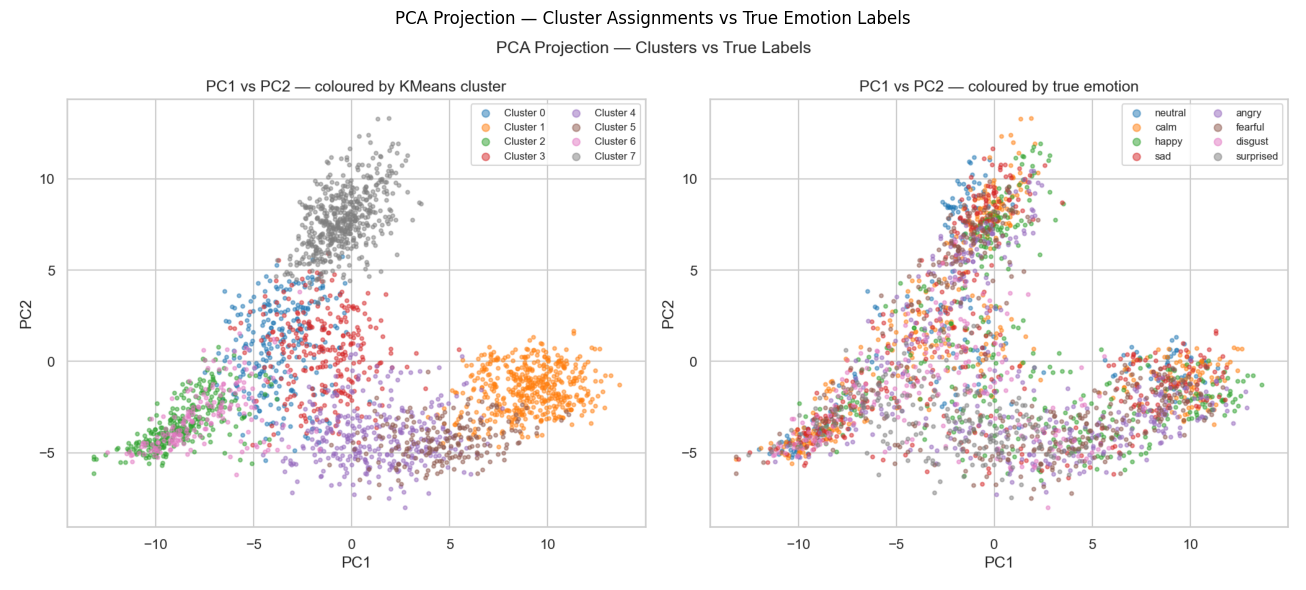

In [15]:
show('cluster_scatter.png', 'PCA Projection — Cluster Assignments vs True Emotion Labels', figsize=(14, 6))

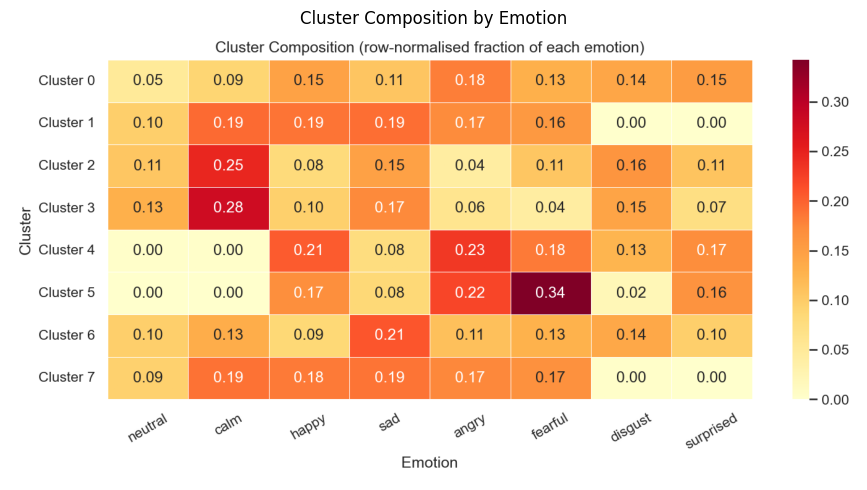

In [16]:
show('cluster_composition.png', 'Cluster Composition by Emotion', figsize=(10, 5))

### Clustering Results Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Silhouette Score | 0.133 | Very low — clusters overlap significantly |
| Mean Cluster Purity | 0.234 | Each cluster is ~23% dominated by one emotion |
| Adjusted Rand Index | ~0.05 | Near-random alignment with true labels |
| Normalized Mutual Info | ~0.07 | Very low shared information |

The low ARI and NMI confirm what the scatter plot shows visually: emotion classes do not form compact, separable clusters in acoustic feature space. The k-means solution maps multiple clusters to *calm* (4 of 8), reflecting that this emotion dominates the centroid-seeking objective. Even the highest-purity cluster (cluster 5 → fearful at 34.2%) contains significant contamination from other classes.

**Conclusion:** SER is fundamentally a supervised learning problem. The acoustic space does not have a natural clustering structure that corresponds to human-defined emotion categories. This is consistent with the broader literature, which consistently shows that unsupervised methods alone fail to capture the complexity of emotional expression.

---
## 7. Dimensionality Reduction

### 7.1 PCA Variance Analysis

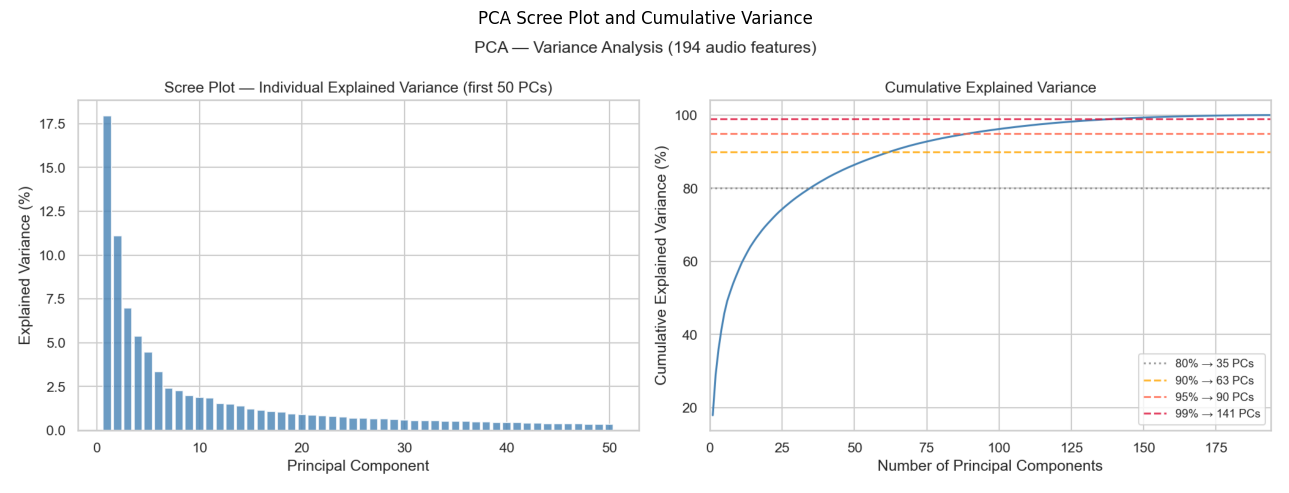

In [17]:
show('pca_scree_cumvar.png', 'PCA Scree Plot and Cumulative Variance', figsize=(13, 5))

| Variance threshold | Components needed |
|-------------------|-------------------|
| 80% | 35 |
| 90% | 63 |
| 95% | 90 |
| 99% | 141 |
| 100% | 194 |

The rapid initial drop in the scree plot (PC1 explains 17.9%, PC2 11.1%) confirms high redundancy among the 194 features — many MFCC statistics capture overlapping aspects of the spectral envelope.

### 7.2 Classifier Performance vs n_components

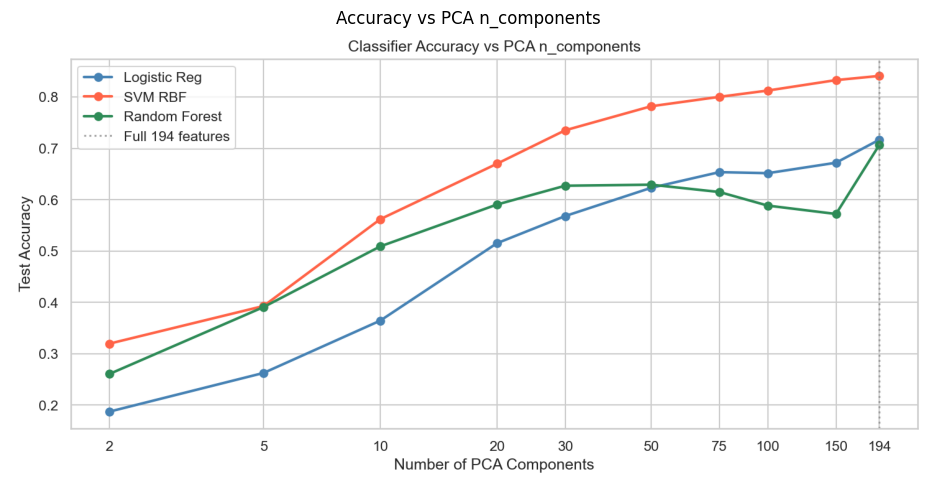

In [18]:
show('pca_clf_sweep.png', 'Accuracy vs PCA n_components', figsize=(10, 5))

All three classifiers plateau by ~50–75 PCA components, with negligible gain from adding more. This means we can achieve near-full accuracy with a **4× reduction in dimensionality**.

### 7.3 t-SNE Visualisation

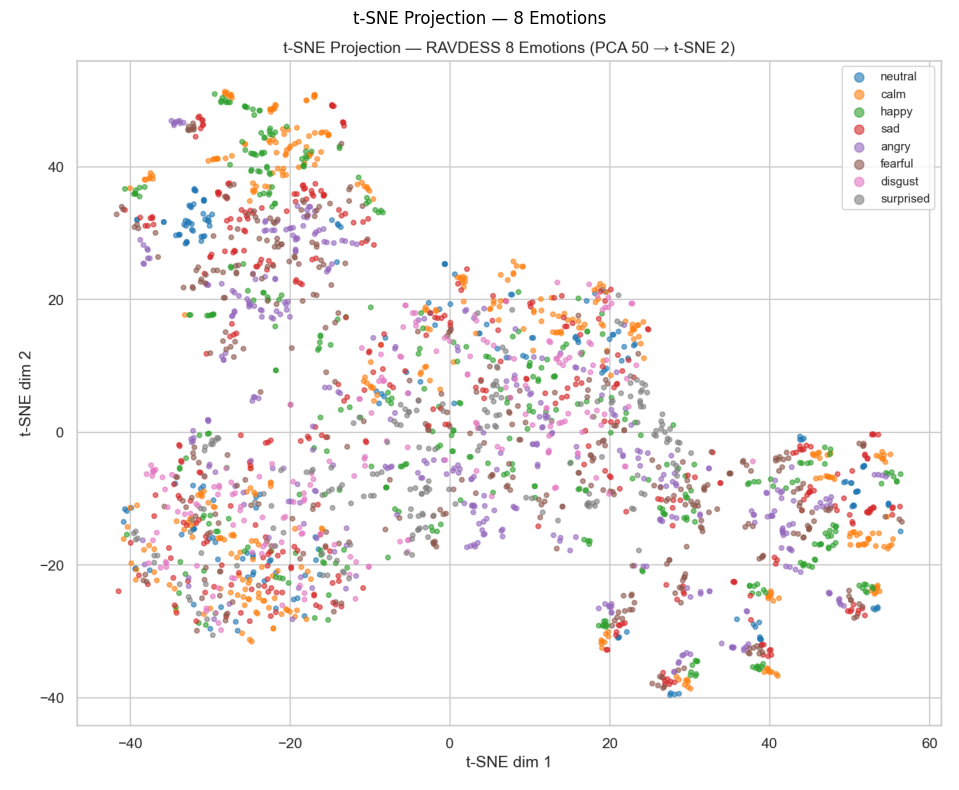

In [19]:
show('tsne_emotions.png', 't-SNE Projection — 8 Emotions', figsize=(10, 8))

The t-SNE plot (perplexity=40, PCA-50 initialisation) shows substantial overlap between all 8 emotion classes, with no clean separation. There are partial local groupings — angry samples cluster more tightly in places, and neutral/calm samples appear somewhat co-located — but no class achieves clean isolation. This explains why even the best classifier caps at ~84% and why the clustering analysis fails.

---
## 8. Discussion

### Key Findings

**1. RBF-SVM is the strongest single model.** Achieving 84.1% test accuracy and 0.979 macro AUC, the RBF-kernel SVM with C=100 outperforms all other models on this dataset. The kernel trick maps the 194-dimensional feature space to an infinite-dimensional space where the emotion classes become approximately linearly separable. Logistic Regression — a purely linear model — achieves 73.1%, so the non-linear RBF boundary adds a clear ~11 percentage point improvement.

**2. MiniLearn MLP nearly matches the best ensemble methods.** At 80.4%, our from-scratch MLP (256-128 architecture, Adam optimiser, 100 epochs) is competitive with XGBoost (79.6%) and beats Gradient Boosting (75.8%), Random Forest (70.7%), and sklearn's Linear SVC (72.1%). This demonstrates that a well-implemented neural network can be highly competitive on audio feature vectors.

**3. Boosting does not dominate on this task.** XGBoost and Gradient Boosting are often considered state-of-the-art for tabular data, yet here they underperform SVM RBF. This is likely because SVM's max-margin objective is particularly well-suited to the high-dimensional, standardised feature space, while boosting's sequential correction of errors offers less benefit when the base learner (decision tree) struggles with audio features.

**4. MFCCs are the dominant features.** Across all selection methods (ANOVA F-test, RF importance, visual inspection), MFCC means and standard deviations — particularly the first few coefficients — are the most discriminative. RMS energy is the second strongest group. Chroma features, while useful for music, contribute less for speech-only emotion.

**5. Unsupervised learning fails on this task.** K-Means achieves mean cluster purity of only 23.4% (ARI ≈ 0.05), barely above random. Emotion is not an acoustic cluster — it is a human construct that requires training signal to learn.

### Surprises

- **Logistic Regression beats many ensembles.** We expected ensemble methods to dominate. Instead, LR at 73.1% beats Random Forest (70.7%) and nearly matches sklearn's linear SVC (72.1%), despite being a strictly linear model. After standardisation, audio features appear to be largely linearly separable.
- **MiniLearn DT outperforms sklearn DT** (49.1% vs 44.8%). The percentile-based threshold sampling in MiniLearn accidentally found better splits in this particular run, likely due to the reduced search space avoiding local optima that the exhaustive sklearn search fell into.
- **AdaBoost underperforms** despite being a strong boosting method. With stumps (max_depth=2) and 200 rounds, it only reaches 51.7% — below even KNN. Audio emotion features require deeper trees to capture meaningful interactions, making stumps a poor weak learner choice here.

### Limitations

1. **Actor-independent evaluation is not guaranteed.** We split randomly by file, not by actor. In a real deployment, the system must generalise to unseen speakers. A leave-one-actor-out evaluation would give a more honest estimate of generalisation.
2. **Hand-crafted features have a ceiling.** The t-SNE plot shows that 194 statistical summaries cannot fully separate all 8 emotions. End-to-end models (CNN on spectrograms, wav2vec 2.0, HuBERT) would likely push accuracy above 90% by learning task-relevant representations directly from the signal.
3. **Class imbalance.** Neutral and disgust have ~50% fewer samples. While macro-F1 mitigates this, a more careful treatment (SMOTE oversampling, class-weighted loss) could improve performance on these minority classes.
4. **Song vs. speech are mixed.** RAVDESS includes both speech and song files. The acoustic properties differ substantially; training separate models for each modality could improve results.

### What We Would Do Differently

- Implement leave-one-speaker-out cross-validation to measure true speaker-independent accuracy
- Use a pre-trained audio encoder (wav2vec 2.0 or HuBERT) for feature extraction instead of hand-crafted statistics
- Apply class-weighted training for minority emotions (neutral, disgust)
- Implement hyperparameter tuning for the MLP (learning rate schedule, dropout, depth)

---
## 9. Conclusion

We built a complete SER pipeline from raw audio to trained classifiers, along with the MiniLearn library implementing 7 classifiers, PCA, K-Means, metrics, and cross-validation from scratch. On the 8-class RAVDESS task:

- **Best model:** RBF-SVM at **84.1% accuracy, 0.837 macro-F1, 0.979 AUC**
- **Best MiniLearn model:** MLP (256-128) at **80.4% accuracy, 0.802 macro-F1**
- **Feature insight:** 50 PCA components suffice for near-full accuracy; MFCCs + RMS energy drive discrimination
- **Clustering verdict:** Emotion recognition requires supervised learning — unsupervised clustering fails (ARI ≈ 0.05)

The project demonstrates that carefully engineered acoustic features combined with a well-tuned kernel SVM can achieve strong SER performance without deep learning. However, the t-SNE visualisation and clustering results make clear that meaningful further progress will require end-to-end learned representations.

---
## 10. References

1. Livingstone SR, Russo FA (2018). *The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS): A dynamic, multimodal set of facial and vocal expressions in North American English.* PLoS ONE 13(5): e0196391. https://doi.org/10.1371/journal.pone.0196391

2. RAVDESS Dataset on Zenodo: https://zenodo.org/records/1188976

3. McFee B, et al. (2015). *librosa: Audio and music signal analysis in Python.* Proceedings of the 14th Python in Science Conference. https://librosa.org

4. Pedregosa F, et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, pp. 2825–2830.

5. Chen T, Guestrin C (2016). *XGBoost: A Scalable Tree Boosting System.* KDD '16. https://doi.org/10.1145/2939672.2939785

6. Kingma DP, Ba J (2014). *Adam: A Method for Stochastic Optimization.* ICLR 2015. https://arxiv.org/abs/1412.6980

7. van der Maaten L, Hinton G (2008). *Visualizing Data using t-SNE.* JMLR 9, pp. 2579–2605.